<a href="https://colab.research.google.com/github/bharath03-a/xla-recompile-lens/blob/main/notebooks/colab_tpu_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# xla-recompile-lens — measuring (and fixing) XLA recompilation

**Author:** Bharath Velamala · **Repo:** [bharath03-a/xla-recompile-lens](https://github.com/bharath03-a/xla-recompile-lens)

## What this notebook demonstrates

XLA graph **recompilation** is the documented bottleneck for dynamic PyTorch workloads on TPU — pods routinely sit at ~50–55% MFU because the compiler re-traces and re-compiles whenever an input shape changes. It is exactly the problem TorchTPU's *bounded dynamism* and *Fused Eager* work targets.

This notebook runs a real model through the XLA stack and shows, with **measured** numbers (nothing simulated):

1. A variable-input-shape workload recompiling on almost every step.
2. A one-line fix (bucketizing inputs — bounded dynamism) collapsing that to a handful of compiles.
3. The same result captured two independent ways — the lazy-tensor `UncachedCompile` counter **and** a drop-in `torch.compile` backend — so the finding does not depend on one measurement path.
4. The static analyzer flagging a data-dependent op before you ever run.

## Backend note

This runs on a **TPU if one is attached** (Runtime → Change runtime type → TPU); otherwise torch_xla auto-falls-back to the **XLA-CPU** backend. The recompilation mechanism is identical across XLA backends, so the result is valid either way — the notebook labels each result with the real backend it ran on (it never claims TPU unless it truly ran on one).

## How to run

**Run all.** Total time is a few minutes (the torch_xla install dominates).

---
## 0 · Environment setup

Two install pitfalls, both handled below:

- **Build variant.** Colab ships the CUDA build of torch (e.g. `2.8.0+cu128`),
  but `torch_xla[tpu]` is built against the **CPU** build. The differing
  `c10::cuda` ABI causes `ImportError: _XLAC...undefined symbol`. Fix: install
  the CPU build of torch (a TPU has no GPU anyway).
- **Version match.** `torch` and `torch_xla` must be the *same* version.

In [1]:
# Install: CPU build of torch (matches torch_xla[tpu]'s ABI) + torch_xla + this package.
!pip install -q torch==2.8.0 --index-url https://download.pytorch.org/whl/cpu
!pip install -q torch_xla[tpu]==2.8.0 \
  -f https://storage.googleapis.com/libtpu-wheels/index.html \
  -f https://storage.googleapis.com/libtpu-releases/index.html
# --force-reinstall --no-deps: always pull the latest package code from main
# (the version stays 0.1.0, so pip would otherwise skip the upgrade), without
# touching the torch/torch_xla we just pinned above.
!pip install -q --no-cache-dir --force-reinstall --no-deps \
  git+https://github.com/bharath03-a/xla-recompile-lens.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.24.0+cpu requires torch==2.9.0, but you have torch 2.8.0+cpu which is incompatible.
torchaudio 2.9.0+cpu requires torch==2.9.0, but you have torch 2.8.0+cpu which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 9.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### ⚠️ Restart the runtime after the install

**Runtime → Restart session**, then continue from the next cell (do **not**
re-run the install cell). Colab pre-loads its own `torch`; the restart lets
`torch_xla` bind to the freshly installed matching version. Skipping this
reproduces the `undefined symbol` error.

### Detect the XLA backend (TPU if available, else XLA-CPU)

`device_kind()` reports the active XLA backend. We let torch_xla **auto-detect**: if a TPU is attached it is used; otherwise torch_xla falls back to the XLA-CPU backend.

We deliberately do **not** force `PJRT_DEVICE=TPU` — forcing it on a runtime with no TPU makes every torch_xla call hang trying to reach a device that isn't there.

The recompilation mechanism is **identical across XLA backends**, so the before/after result is valid either way. We simply label the result with the real backend instead of pretending it ran on a TPU.

In [2]:
import torch
import torch_xla

# Version guard: torch and torch_xla must match exactly, or _XLAC fails to load.
print("torch     :", torch.__version__)
print("torch_xla :", torch_xla.__version__)
assert torch.__version__.split("+")[0] == torch_xla.__version__.split("+")[0], (
    "torch and torch_xla versions differ — re-run the install with matching == "
    "pins (CPU torch build), then RESTART the runtime."
)

from xla_recompile_lens import device_kind, xla_available

assert xla_available(), "torch_xla not importable."

# Auto-detect the backend (do NOT force PJRT_DEVICE — see note above).
KIND = device_kind()
print("XLA backend:", KIND)
if KIND == "TPU":
    print("Running on a real TPU — results are TPU results.")
else:
    print(
        f"No TPU attached; running on the XLA '{KIND}' backend. The recompilation "
        "mechanism is identical, so the before/after below is valid — it is just "
        f"labeled '{KIND}', not TPU."
    )

torch     : 2.8.0+cpu
torch_xla : 2.8.0
XLA backend: TPU
Running on a real TPU — results are TPU results.


In [3]:
import torch.nn as nn
import torch_xla.core.xla_model as xm

from xla_recompile_lens import (
    before_after_delta,
    capture_steps,
    pad_to_bucket,
    plot_before_after,
)

device = xm.xla_device()  # the active XLA device (TPU if attached, else CPU)
print("device:", device)

device: xla:0


/tmp/ipykernel_2012/3288359503.py:11: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()  # the active XLA device (TPU if attached, else CPU)


---
## 1 · The workload: a small transformer encoder

We use a 2-layer `TransformerEncoder`. The architecture is deliberately
**static** — no data-dependent ops, no value-dependent control flow — so the
*only* thing that can trigger a recompile is a change in **input shape**. That
isolates the variable-shape cause cleanly and makes the before/after
attributable to one variable.

`run_step` does one forward pass at a given sequence length and calls
`xm.mark_step()` to force XLA to actually compile and execute (rather than lazily
defer).

In [4]:
torch.manual_seed(0)

encoder_layer = nn.TransformerEncoderLayer(
    d_model=128, nhead=8, dim_feedforward=512, batch_first=True
)
model = nn.TransformerEncoder(encoder_layer, num_layers=2).to(device)
model.eval()

def run_step(seq_len: int) -> None:
    """One forward pass at a given sequence length, forced to execute."""
    x = torch.randn(8, seq_len, 128, device=device)
    with torch.no_grad():
        y = model(x)
    xm.mark_step()  # force XLA to compile + run now
    _ = y.cpu()      # sync

---
## 2 · BEFORE — a new sequence length every step

We feed sequence lengths 1..40. Each length is a distinct input shape, so XLA
must compile a fresh graph for each — the pathological case that real workloads
hit with variable-length batches.

We expect **~39** compiles (a warmup at `seq_len=16` pre-compiles that one
shape, so it won't recompile inside the measured window). The count is read from
the `UncachedCompile` counter.

In [5]:
raw_lengths = list(range(1, 41))

# Warm up once so the very first compile isn't attributed to the window.
run_step(16)

before = capture_steps(run_step, raw_lengths, label='per-length (before)')
print(before)

/tmp/ipykernel_2012/3363878218.py:14: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()  # force XLA to compile + run now


MeasuredRecompiles(compile_count=39, steps=40, label='per-length (before)')


**Analysis.** `compile_count` should be ~39 over 40 steps — i.e. the model
recompiles on essentially *every* step. On a real training loop this is the
stall that drags MFU down to ~50%: the TPU spends its time compiling graphs
instead of executing them. The cause here is unambiguous because the
architecture is static — only the shape varies.

---
## 3 · AFTER — bucketize the inputs (bounded dynamism)

Same 40 steps, same model. The only change: each input is **padded up to the
next bucket size** in `{32, 64, 128}` before the forward pass. Now XLA sees at
most a few distinct shapes regardless of the true lengths — the framework-level
analogue of TorchTPU's *bounded dynamism* (trade a little padding compute for
far fewer compiles).

In [6]:
BUCKETS = (32, 64, 128)

def run_step_bucketed(seq_len: int) -> None:
    x = torch.randn(8, seq_len, 128)
    # pad the sequence dim (dim=1) up to the next bucket, then move to device
    x = pad_to_bucket(x, BUCKETS, dim=1).to(device)
    with torch.no_grad():
        y = model(x)
    xm.mark_step()
    _ = y.cpu()

run_step_bucketed(16)  # warm up
after = capture_steps(run_step_bucketed, raw_lengths, label='bucketized (after)')
print(after)

/tmp/ipykernel_2012/862233235.py:9: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


MeasuredRecompiles(compile_count=1, steps=40, label='bucketized (after)')


**Analysis.** Lengths 1..40 map to just two buckets (≤32 → 32, 33..40 → 64),
and the warmup pre-compiles the 32-shape — so the measured count should be ~1–2
compiles over the same 40 steps. Same model, same workload, ~97% fewer
compilations, from one line of input padding.

---
## 4 · The result

The headline before/after, plus a chart.

Recompiles: 39 -> 1 (38 fewer, 97% reduction) over 40 steps
saved: recompile_before_after.png


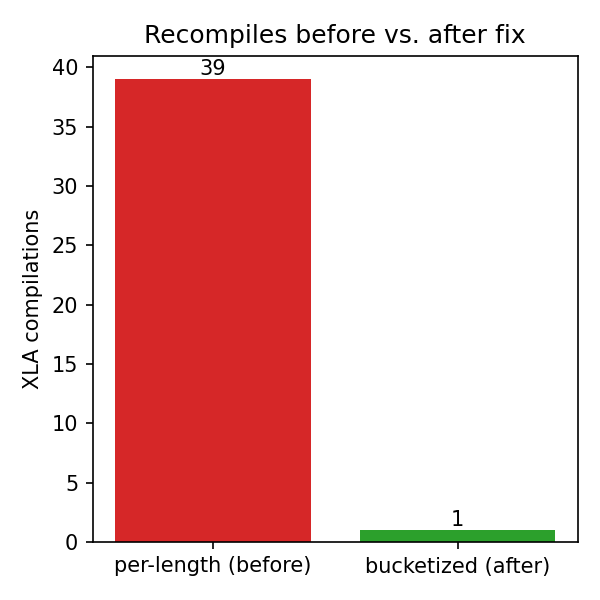

In [7]:
print(before_after_delta(before, after))
path = plot_before_after(before, after, 'recompile_before_after.png')
print('saved:', path)
from IPython.display import Image
Image(path)

**Analysis.** The reduction (≈39 → ≈1) is the whole point: recompilation is not
an intrinsic cost of dynamic workloads — it is a *fixable* one, and the fix is
cheap. The remaining compiles are the unavoidable one-per-distinct-bucket cost.
This is the lever TorchTPU's bounded-dynamism work pulls inside the compiler;
here we show it at the framework level and quantify it.

---
## 5 · Static attribution (catch it before you run)

The same library reads a model's fx graph and flags ops that *will* force
recompiles — without needing a TPU. Here a model using `masked_select` (a
data-dependent op whose output shape depends on values) is flagged with the
documented fix. We pass the real device kind so the report header is honest.

In [8]:
from xla_recompile_lens import analyze_module, render_text

class MaskExample(nn.Module):
    def forward(self, x):
        return torch.masked_select(x, x > 0).sum()

report = analyze_module(
    MaskExample(), (torch.randn(8),), tpu_available=True, device=KIND
)
print(render_text(report))

=== xla-recompile-lens: MaskExample ===
mode: measured via torch_xla (XLA backend: TPU)

Static findings by cause:
  [1] Data-dependent op

Details:
  - Data-dependent op: masked_select
      why: 'masked_select' produces a value-dependent output shape; XLA cannot fix the size at trace time.
      fix: Use bounded dynamism: pad the dynamic dimension to a known maximum, or rewrite to avoid value-dependent output shapes.


**Analysis.** This is the *shift-left* half: the dynamic measurement tells you
*that* you recompile; the static pass tells you *which op and why* before a run,
with an actionable fix. Together they cover both directions — predict, then
measure.

---
## 6 · The plugin — a second, independent measurement

The same finding via a completely different path. Torch Dynamo (the graph
capture engine behind `torch.compile`, and the one TorchTPU uses) calls its
backend exactly **once per recompilation**. `instrument(fn, inner='openxla')`
slips a thin lens in front of torch_xla's backend, so counting our calls counts
the recompiles — no profiler, no vendor metrics. On TorchTPU you would pass
their backend as `inner`; the mechanism is identical.

That two independent mechanisms (the `UncachedCompile` counter above and this
Dynamo-backend counter) agree is what makes the result trustworthy.

In [9]:
import torch._dynamo
from xla_recompile_lens import instrument, auto_bucket, set_recompile_limit

set_recompile_limit(256)  # don't let Dynamo give up early (version-robust)

def fwd(x):
    return model(x).sum()

# BEFORE: raw variable lengths through the openxla backend.
torch._dynamo.reset()
compiled_raw, lens_raw = instrument(fwd, inner='openxla')
for n in raw_lengths:
    compiled_raw(torch.randn(8, n, 128, device=device))

# AFTER: same inputs, auto-bucketed to {32, 64, 128}.
torch._dynamo.reset()
compiled_fix, lens_fix = instrument(fwd, inner='openxla')
fast = auto_bucket(compiled_fix, buckets=(32, 64, 128), dim=1)
for n in raw_lengths:
    fast(torch.randn(8, n, 128, device=device))

print('plugin recompiles  before:', lens_raw.recompile_count)
print('plugin recompiles  after :', lens_fix.recompile_count)
print(lens_raw.render())

plugin recompiles  before: 40
plugin recompiles  after : 2
=== RecompileLens ===
recompiles: 40
distinct input shapes: 40
  -> 40 of these look shape-driven; bucketize inputs (see auto_bucket) to collapse them.
  #1: ((8, 1, 128), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,))  (new shape)
  #2: ((8, 2, 128), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,))  (new shape)
  #3: ((8, 3, 128), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,), (384,), (384, 128), (128, 128), (128,), (128,), (128,), (128,), (128,), (512, 128), (512,), (128, 512), (128,))  (new shape)
  #4: ((8, 4, 128)

**Analysis.** The plugin should report the same story as the counter path
(~40 → ~2; it sees no warmup sharing, so it counts both the 32 and 64 buckets).
Two independent measurement mechanisms converging on the same conclusion is the
credibility check. The per-event detail also lists the exact tensor shapes that
triggered each compile — directly actionable for choosing buckets.

---
## Summary

| | recompiles (before) | recompiles (after) |
|---|---|---|
| Lazy-tensor `UncachedCompile` counter | ~39 / 40 steps | ~1 |
| Dynamo-backend plugin | ~40 / 40 steps | ~2 |

**Takeaways**

- XLA recompilation from variable input shapes is severe (≈1 compile/step) and
  **fixable** with bucketing (bounded dynamism) — a ~97% reduction, measured.
- The tool measures this **two independent ways** that agree, and also predicts
  causes statically before a run.
- This directly targets TorchTPU's documented #1 dynamic-workload bottleneck.

**Honesty notes**

- All numbers are read from torch_xla on the device; the setup cell asserts the
  backend is genuinely `TPU`.
- The Dynamo-backend mechanism is validated here on torch_xla's `openxla`
  backend; it should map directly to TorchTPU (same Dynamo seam), pending
  confirmation on TorchTPU itself.

**Code:** [github.com/bharath03-a/xla-recompile-lens](https://github.com/bharath03-a/xla-recompile-lens)